In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pickle
import os 

from scipy.special import lambertw
from scipy.stats import poisson 

import scipy.sparse

# Plot

In [2]:
# ! cp -r ~/adipose_ln/atac/res/VIB_10xmultiome_2_OG/cluster_barcodes/ ~/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000/.

In [3]:
precision=1e-10

fig_res_dir = '/mnt/hdd_bob/syy/adipose/atac/res/AB_ATAC_FL_TAM_SQ/figures/fig_seqdepth_mixdist'

In [4]:
ws = 3000

output_dir = f'/mnt/hdd_bob/syy/adipose/atac/res/AB_ATAC_FL_TAM_SQ_WS{ws}'
chromosome = 'chr1'

crbarcode_file = os.path.join(output_dir, 'CR_outs/barcodes.tsv')

frag_overlap_subdir = os.path.join(output_dir, 'fragments_overlap_peaks')


In [5]:
tn5_inser_freq_file = os.path.join(output_dir, f'{chromosome}_insert_frequency.pickle')

with open(tn5_inser_freq_file, 'rb') as f:
    tn5_insert_freq = pickle.load(f)

In [6]:
entropy_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy.pickle')

with open(entropy_file, 'rb') as f:
    entropy_dict = pickle.load(f)
    
    
entropy = np.array(list(entropy_dict.values()))
entropy.sort() # sort the entropy values


bc_entropy = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['entropy'])



In [7]:
summary_statistics_frag_overlap_entropypeaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                          'summary_statistics_frag_overlap_entropypeaks.csv'), sep='\t', 
                                                              index_col=0)
summary_statistics_frag_overlap_entropypeaks_df.index.name = None

summary_statistics_frag_overlap_peaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                 'summary_statistics_frag_overlap_peaks.csv'), sep='\t', 
                                                     index_col=0)
summary_statistics_frag_overlap_peaks_df.index.name = None

In [8]:
entropy_df = summary_statistics_frag_overlap_entropypeaks_df.join(summary_statistics_frag_overlap_peaks_df,
                                                                  lsuffix='_entropypeaks', rsuffix='_peaks')

entropy_df = entropy_df.join(bc_entropy, how='outer')

In [9]:
poisson.logpmf(10, 5)

-4.010033448734513

In [10]:
def mle_estimate(tn5_insert_array:scipy.sparse, print_debug:bool=False, return_freq:bool=False):
    
    flag = None
    Mtotal = tn5_insert_array.shape[1] # total number of windows
    
    row_indices, col_indices =tn5_insert_array.nonzero()
    non0_insert = tn5_insert_array[row_indices, col_indices].toarray().flatten()
    Mp = non0_insert.shape[0]
    
    cur, freq = np.unique(non0_insert, return_counts=True)
    
    non0_insert_adjusted = (non0_insert + 1) // 2 # adjust for paired-end sequencing
    cur_adjusted, freq_adjusted = np.unique(non0_insert_adjusted, return_counts=True)
    
    p_non0 = freq_adjusted / Mp
    mean_adjusted = np.sum( cur_adjusted * p_non0 )

    # Lambert W function requires (-M1 * exp(-M1)) >= -1/e
    if mean_adjusted <= 1:
        mle_lambda = None
        P0 = None
        if return_freq:
            return Mtotal, Mp, mean_adjusted, mle_lambda, P0, cur_adjusted, freq_adjusted, cur, freq, flag
        return Mtotal, Mp, mean_adjusted, mle_lambda, P0, flag

    mle_lambda = lambertw( -mean_adjusted * np.exp(-mean_adjusted) , k=0).real + mean_adjusted
    P0 = np.exp(-mle_lambda)
    
    if mle_lambda <= 0:
        P0 = None
    
    if return_freq:
        return Mtotal, Mp, mean_adjusted, mle_lambda, P0, cur_adjusted, freq_adjusted, cur, freq, flag
    return Mtotal, Mp, mean_adjusted, mle_lambda, P0, flag


def kl_divergence(mle_lambda, cur, freq):
    """ Compute KL divergence D_KL(P||Q) for discrete distributions
        p and q are arrays of the same length representing probability distributions
    """
    # q is from Poisson distribution with parameter mle_lambda
    
    p = freq / np.sum(freq)
    log_q = np.array([poisson.logpmf(k, mle_lambda) for k in cur]) 
    
    divergence = np.sum( p * (np.log(p) - log_q) )
    
    return divergence

In [11]:
# Calculate Entropy using MLE estimate 
def mixdist_mle_entropy(tn5_insert_array:scipy.sparse):
    Mtotal, Mp, mean_non0, mle_lambda, p0, cur_adjusted, freq_adjusted,  cur, freq, flag = mle_estimate(tn5_insert_array, return_freq=True)

    if p0 is None:
        Entropy_mixturedist = None
        Entropy_open_region = None
        Entropy_open_region_noadj = None
        divergence = None
        p_closed_state = None
    else:
        Nwindows_0inser_open_region = np.floor(Mp / ( 1- p0) * p0 )
        Nwindows_0inser_open_region = np.min((Nwindows_0inser_open_region, Mtotal - Mp))
        Nwindows_closed_region = int(Mtotal - Mp - Nwindows_0inser_open_region)

        #total_freq = np.concatenate(([Nwindows_closed_region, Nwindows_0inser_open_region], freq_adjusted))

        # calculate entropy of mix states
        p_closed_state = Nwindows_closed_region / Mtotal
        p_states = np.array([p_closed_state, 1 - p_closed_state])
        Entropy_state = -np.sum(p_states * np.log2(p_states))
        
        # calculate entropy as a mixture distribution 
        if Nwindows_0inser_open_region > 0:
            open_region_p = np.concatenate( ([Nwindows_0inser_open_region ], freq_adjusted) )
        else:
            open_region_p = freq_adjusted
        open_region_p = open_region_p / (Mp + Nwindows_0inser_open_region)
        Entropy_open_region = -np.sum(open_region_p * np.log2(open_region_p))

        # # Calculate the open region entropy using unadjusted freq (for comparison)
        p = freq/Mp
        Entropy_open_region_noadj = -np.sum(p * np.log2(p))
        
        Entropy_mixturedist = Entropy_state + (1 - p_closed_state) * Entropy_open_region
        # flag =  Entropy_state + (1 - p_closed_state) * Entropy_open_region_noadj # to test the difference
        #Entropy_mixturedist = Entropy_state + (1 - p_closed_state) * entropy_non0_part # without adjusted
        divergence = kl_divergence(mle_lambda, cur_adjusted, freq_adjusted)
    return Entropy_mixturedist, Entropy_open_region, Entropy_open_region_noadj, mle_lambda, p0, p_closed_state, divergence

In [12]:
# calcualte entropy without 0-insertion windows 
for bc in tn5_insert_freq.keys():
    if bc not in entropy_df.index:
        continue
    else:
        #Entropy_mixturedist, Entropy_open_region, Entropy_final, other_paras = calcualte_multiple_entropies(tn5_insert_freq[bc].toarray(), return_all_paras=True)
        Entropy_mixturedist, Entropy_open_region, Entropy_open_region_noadj, mle_lambda, p0, p_closed_state, divergence = mixdist_mle_entropy(tn5_insert_freq[bc])
        entropy_df.loc[bc, 'entropy_mixdist_c'] = Entropy_mixturedist
        entropy_df.loc[bc, 'entropy_open_region'] = Entropy_open_region
        entropy_df.loc[bc, 'Entropy_open_region_noadj'] = Entropy_open_region_noadj
        entropy_df.loc[bc, 'mle_lambda'] = mle_lambda
        entropy_df.loc[bc, 'P0_open_region'] = p0
        entropy_df.loc[bc, 'p_closed_state'] = p_closed_state
        entropy_df.loc[bc, 'kl_divergence'] = divergence
    
entropy_df[ '1-P0'] = 1- entropy_df['P0_open_region']

In [13]:
a = np.array([100, 100, 10e-8])
b = np.array([10, 40, 150])

a = a/a.sum()
b = b/b.sum()

-np.sum(a * np.log2(a)),  - np.sum(b * np.log2(b))

(1.0000000156700237, 0.9917601481809734)

## Load CR's barcodes info 

In [14]:
crbarcode_file = '/mnt/hdd_bob/syy/adipose/atac/res/AB_ATAC_FL_TAM_SQ/CR_outs/barcodes.tsv'

In [15]:
cr_clustering_df = pd.read_csv(crbarcode_file, sep=',', header=None, names=['barcode'])
cr_clustering_df.set_index('barcode', inplace=True)
cr_clustering_df['cr_bc'] = True

In [16]:
all_df = entropy_df.join(cr_clustering_df, how='outer')
all_df['log(total_fragments)'] = np.log10(all_df['total_fragments_entropypeaks'] + precision)
all_df['log(entropy)'] = np.log10(all_df['entropy'] + precision)
# Create a binary column indicating whether a barcode is a cell by CR's cell calling
all_df['cr_bc'] = ~all_df['cr_bc'].isna()

In [17]:
all_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist_c,entropy_open_region,Entropy_open_region_noadj,mle_lambda,P0_open_region,p_closed_state,kl_divergence,1-P0,cr_bc,log(total_fragments),log(entropy)
AAACAAGCAAACAAAG-1,1,0.0,0.0,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,4.342945e-11,NaN
AAACAAGCAAACATGT-1,1,0.0,0.0,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,4.342945e-11,NaN
AAACAAGCAAACCCAA-1,2,0.0,0.0,2,0.0,0.0,0.000214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,3.010300e-01,-3.668993
AAACAAGCAAACGCGT-1,2,0.0,0.0,2,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,3.010300e-01,NaN
AAACAAGCAAACTGAT-1,1,0.0,0.0,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,4.342945e-11,NaN


# Check 

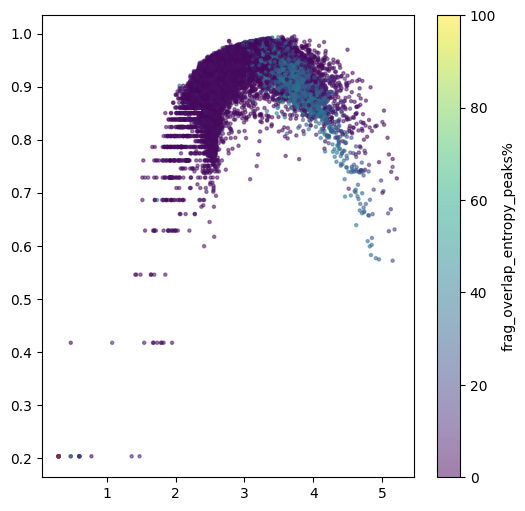

In [18]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter( all_df['log(total_fragments)'], 
              all_df['P0_open_region'], c= all_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')

## Plot Mixture Entropy

## see different entropy calculation

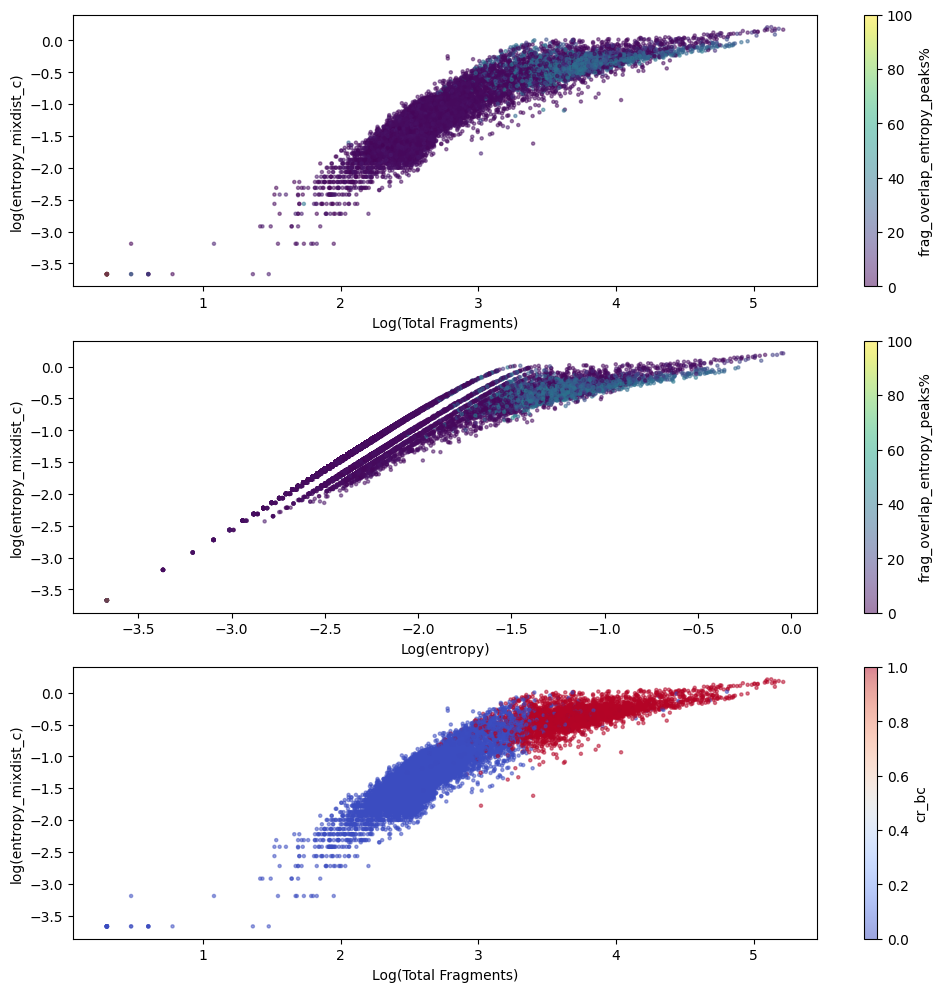

In [19]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist_c']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

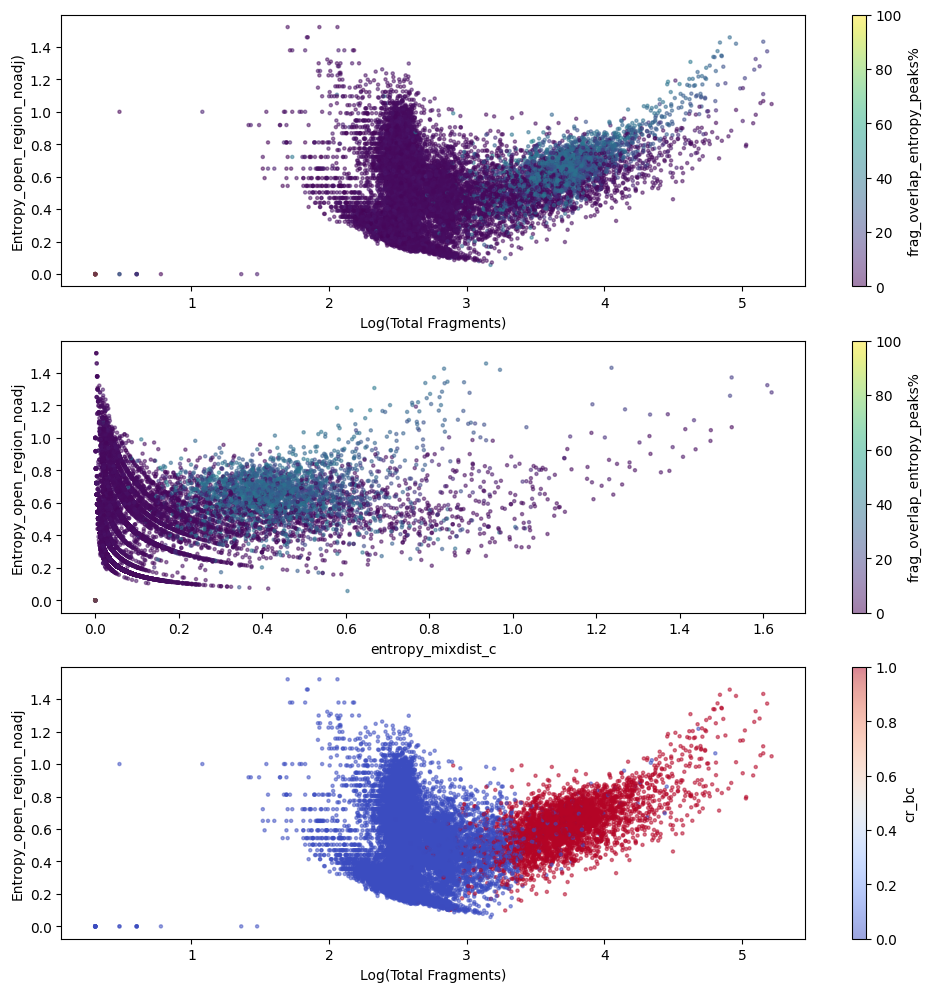

In [20]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], all_df['Entropy_open_region_noadj'], c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('Entropy_open_region_noadj)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['entropy_mixdist_c'], all_df['Entropy_open_region_noadj'], c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('entropy_mixdist_c')
ax[1].set_ylabel('Entropy_open_region_noadj')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], all_df['Entropy_open_region_noadj'],  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('Entropy_open_region_noadj')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


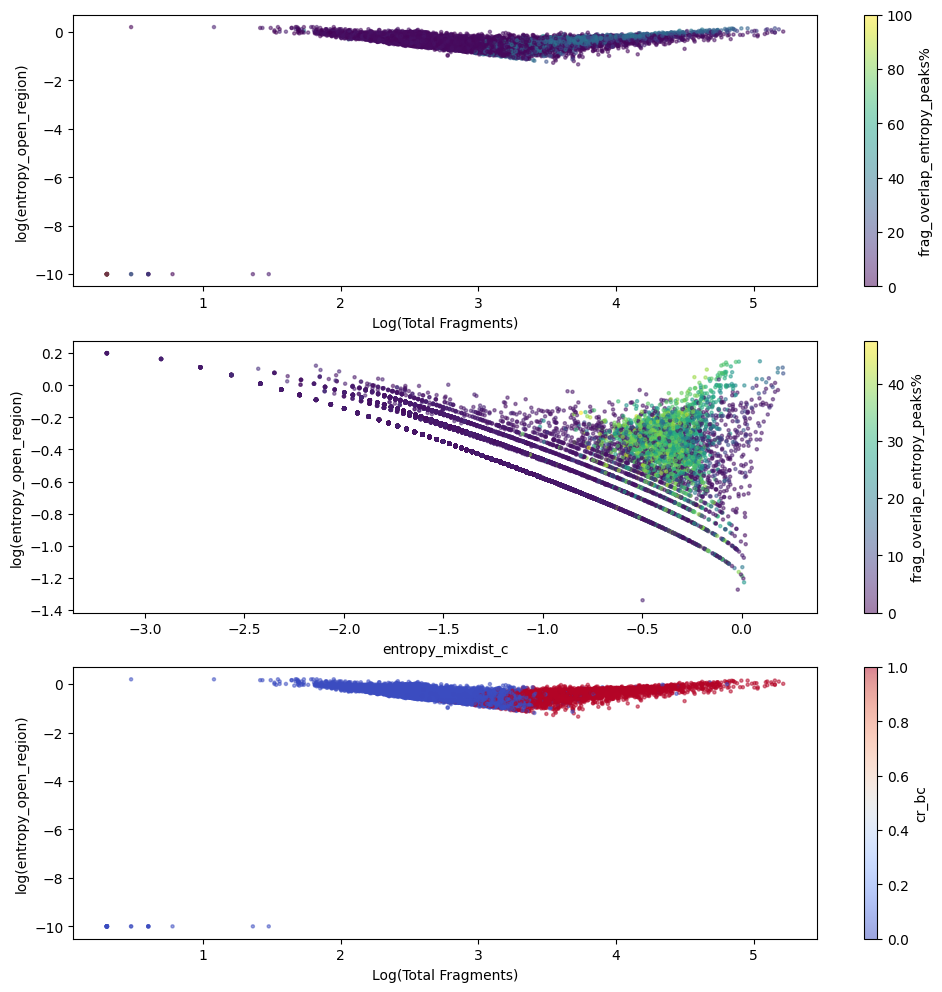

In [21]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_open_region']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_open_region)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(np.log10(all_df['entropy_mixdist_c']), np.log10(all_df['entropy_open_region']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('entropy_mixdist_c')
ax[1].set_ylabel('log(entropy_open_region)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_open_region']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_open_region)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

# And what

In [ ]:
# all_df['entropy_pass'] = (all_df['non0_2ndorder_moment'] / all_df['non0_mean'] - all_df['non0_mean']) < 1

# all_df['entropy_pass2'] = (all_df['non0_2ndorder_moment'] -  all_df['non0_mean'] * (2 - np.exp(-all_df['non0_mean'])) ) < 0 

# all_df['qc'] = all_df['non0_2ndorder_moment'] / all_df['non0_mean'] - all_df['non0_mean']
# np_df = all_df.loc[all_df['qc'] >= 1. ]

# all_df['qc2'] = all_df['non0_2ndorder_moment'] -  all_df['non0_mean'] * (2 - np.exp(-all_df['non0_mean']))
# np_df2 = all_df.loc[all_df['qc2'] >=0 ]



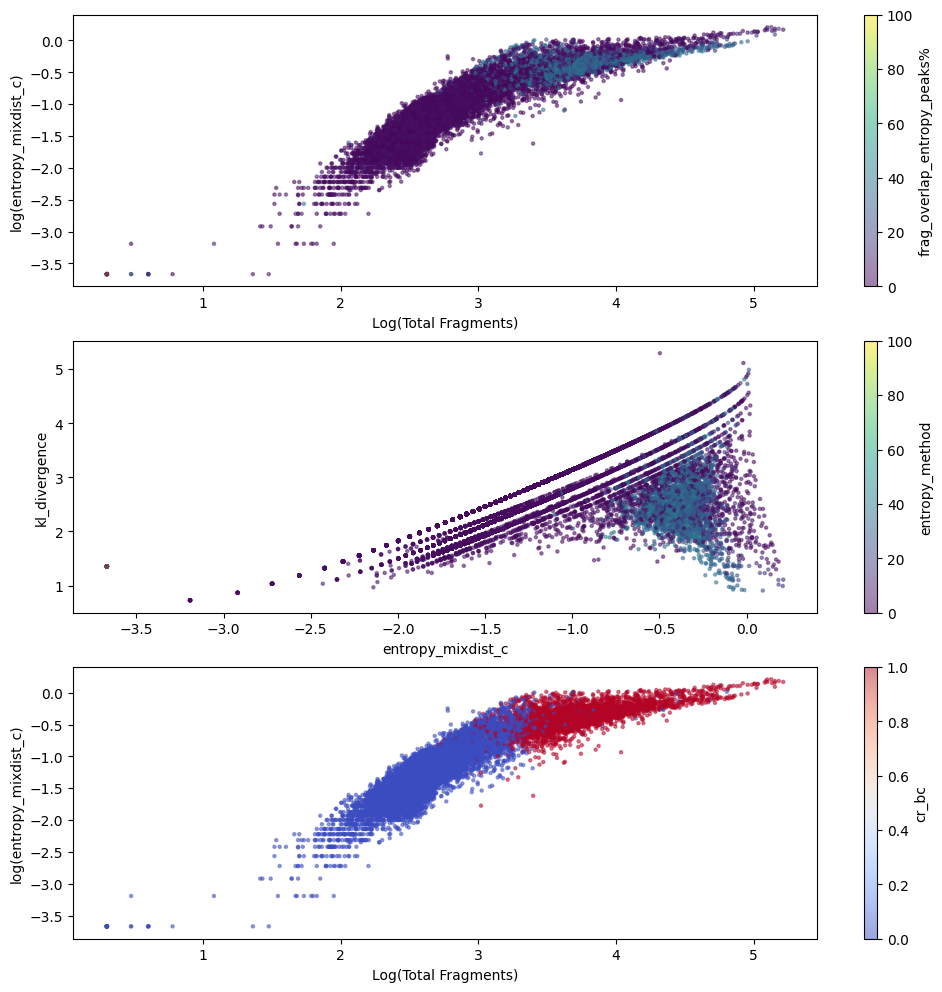

In [35]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

all_df['entropy_pass'] = (all_df['entropy_mixdist_c'] > 10 ** (-0.8)) 
a_df = all_df.loc[all_df['entropy_pass']]
ax[1].scatter( np.log10(all_df['entropy_mixdist_c']), all_df['kl_divergence'],  c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis') #cmap='coolwarm')
ax[1].set_xlabel('entropy_mixdist_c')
ax[1].set_ylabel('kl_divergence')
# ax[1].scatter( a_df['log(total_fragments)'], np.log10(a_df['entropy_mixdist_c']),  c='red', 
#            alpha=0.5, s=5)

fig.colorbar(ax[1].collections[0], ax=ax[1], label='entropy_method')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

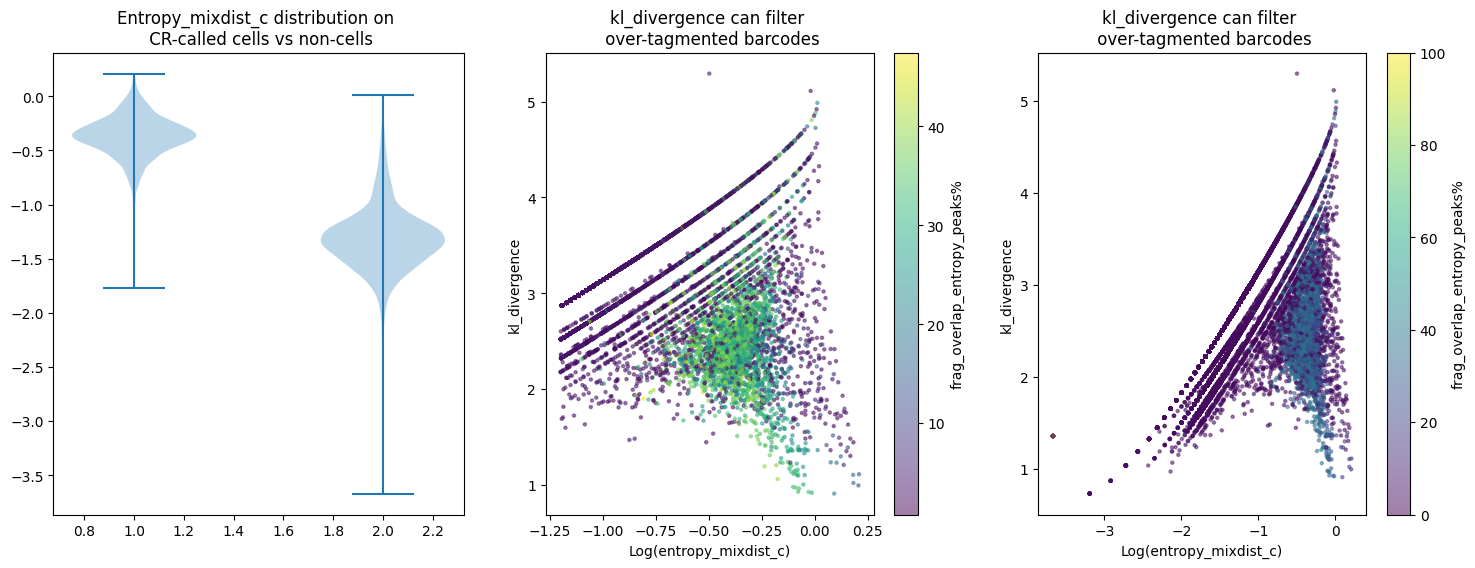

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(18 ,6))
ax = ax.flatten()
ax[0].violinplot([np.log10(all_df.loc[all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision) ,
                          np.log10(all_df.loc[~all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision)],
               showmeans=False)
ax[0].set_title('Entropy_mixdist_c distribution on \n CR-called cells vs non-cells')

a_df =  all_df[all_df['entropy_mixdist_c'] > 10 **(-1.2)]
ax[1].scatter(  np.log10(a_df['entropy_mixdist_c']), a_df['kl_divergence'],  c=a_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy_mixdist_c)')
ax[1].set_ylabel('kl_divergence')
ax[1].set_title('kl_divergence can filter \n over-tagmented barcodes')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')

ax[2].scatter(  np.log10(all_df['entropy_mixdist_c']), all_df['kl_divergence'],  c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[2].set_xlabel('Log(entropy_mixdist_c)')
ax[2].set_ylabel('kl_divergence')
ax[2].set_title('kl_divergence can filter \n over-tagmented barcodes')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='frag_overlap_entropy_peaks%')

### Top 20k as pre-filter

In [ ]:
top20k_df = all_df.sort_values(by='total_fragments_entropypeaks', ascending=False).head(20000)


fig, ax = plt.subplots(1, 1, figsize=(12,12))
ax.scatter( top20k_df['log(total_fragments)'], np.log10(top20k_df['entropy_mixdist_c']+ precision), c=top20k_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')


In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
_ = ax.hist(np.log10(top20k_df['entropy_mixdist_c']), bins=100)

In [ ]:
all_df['cr_bc'].value_counts()

In [ ]:
all_df[all_df['entropy_mixdist_c'] > 10**(-0.7)].shape

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(np.arange(20000), np.log10(top20k_df['entropy_mixdist_c'].sort_values(ascending=False) + precision), s=10)
ax.set_ylabel('log(entropy_mixdist_c)')
ax.set_xlabel('Ranked Barcodes (by entropy_mixdist_c)')

In [ ]:
fig,ax = plt.subplots(figsize=(6,6))
_ = ax.hist(np.log10(all_df['entropy_mixdist_c']+ precision), bins=100)

In [ ]:


special_bc = 'GACAGGCTCGAGGAGG-1'  # bad-quality cell -- probably over-tagmented 

fig, ax = plt.subplots( figsize=(12,12))
ax.scatter( top20k_df['log(total_fragments)'], np.log10(top20k_df['entropy_mixdist_c']), c=top20k_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('log(entropy_mixdist)')

ax.legend()


fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')


# See Tn5 Insertions

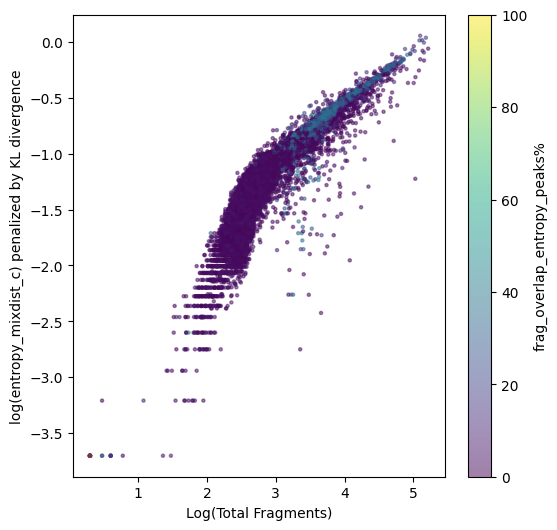

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c'] -(1 - all_df['p_closed_state']) * all_df['kl_divergence']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('log(entropy_mixdist_c) penalized by KL divergence')
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')

## Set 1

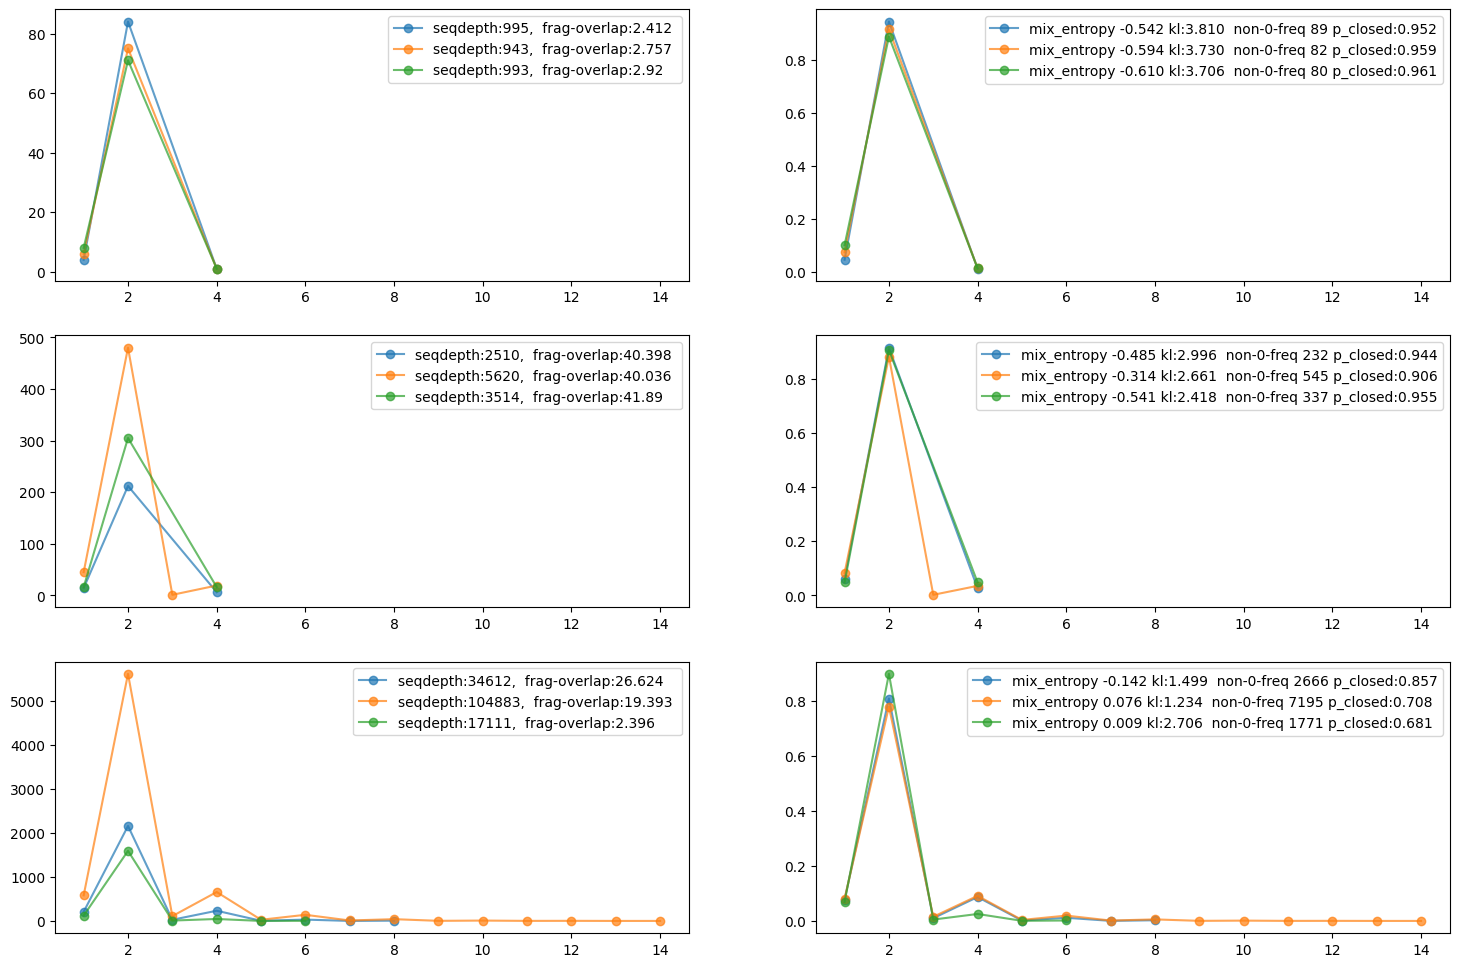

In [72]:
subset_df = all_df[(all_df['frag_overlap_entropy_peaks%'] < 10) & (all_df['kl_divergence'] > 3.7)  & (all_df['entropy_mixdist_c'] > 10 ** (-.8)) ]

good_df = all_df[(all_df['frag_overlap_entropy_peaks%'] > 40) & (all_df['kl_divergence'] < 3) & (all_df['entropy_mixdist_c'] > 10 ** (-.8)) ]

crazy_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-.7)) & (all_df['log(total_fragments)'] > 4)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax =  97, 100

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[sample_bc[0], 'kl_divergence']
        p_closed_state = all_df.loc[sample_bc[0], 'p_closed_state']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])     
        ax[0, 0].plot(val[1:], freq[1:], marker='o', 
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} kl:{kl_divergence_val:.3f}  non-0-freq {freq[1:].sum()} p_closed:{p_closed_state:.3f}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[good_bc[0], 'kl_divergence']
        p_closed_state = all_df.loc[good_bc[0], 'p_closed_state']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} kl:{kl_divergence_val:.3f}  non-0-freq {freq[1:].sum()} p_closed:{p_closed_state:.3f}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[crz_bc[0], 'kl_divergence']
        p_closed_state = all_df.loc[crz_bc[0], 'p_closed_state']
        
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} kl:{kl_divergence_val:.3f}  non-0-freq {freq[1:].sum()} p_closed:{p_closed_state:.3f}',
                alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()
        
        

In [67]:
record_plot_bcs

[['ATGTGGCCACCTTCTC-1', 'bc'],
 ['GGGCAACTCTCAATCG-1', 'good'],
 ['CTTTACTGTGTTACAC-1', 'crazy'],
 ['TTAGTCAGTCAGGCTC-1', 'bc'],
 ['GTTTGCTCAATACCGA-1', 'good'],
 ['TAACCTAGTTGTTCCC-1', 'crazy'],
 ['AATGTGGGTAAGTACG-1', 'bc'],
 ['GGGCCATAGTAAGCTA-1', 'good'],
 ['ATACTGGCAGCAAGTC-1', 'crazy'],
 ['GCGCTACGTCCCTCTG-1', 'bc'],
 ['CTGGCTTAGTTACGTT-1', 'good'],
 ['AAACCGGTCCCTGGTG-1', 'crazy'],
 ['GGAGCATGTGCAAGTA-1', 'bc'],
 ['GTCATCATCCATCACA-1', 'good'],
 ['GCTTCAATCCCAATAT-1', 'crazy'],
 ['TTTACTGCAAGGCTTA-1', 'bc'],
 ['TCAAGTGCATAACCAG-1', 'good'],
 ['CTGTTCAAGTTATGGA-1', 'crazy'],
 ['TTGCATGTCTAGCCTA-1', 'bc'],
 ['GCCCTCAAGTTACTAC-1', 'good'],
 ['TACAACAAGCCAAACG-1', 'crazy']]

In [71]:
all_df.loc['ATGTGGCCACCTTCTC-1'] 

total_fragments_entropypeaks        4450
frag_overlap_entropy_peaks          91.0
frag_overlap_entropy_peaks%     2.044944
total_fragments_peaks               4450
frag_overlap_peaks                  85.0
frag_overlap_peaks%             1.910112
entropy                         0.048406
entropy_mixdist_c               0.789779
entropy_open_region             0.162206
Entropy_open_region_noadj       0.479588
mle_lambda                       0.02366
P0_open_region                  0.976618
p_closed_state                  0.783036
kl_divergence                   3.755884
1-P0                            0.023382
cr_bc                               True
log(total_fragments)             3.64836
log(entropy)                   -1.315105
Name: ATGTGGCCACCTTCTC-1, dtype: object

In [68]:
all_df.loc['GGGCAACTCTCAATCG-1']

total_fragments_entropypeaks         5323
frag_overlap_entropy_peaks         2313.0
frag_overlap_entropy_peaks%      43.45294
total_fragments_peaks                5323
frag_overlap_peaks                 2198.0
frag_overlap_peaks%             41.292504
entropy                           0.05768
entropy_mixdist_c                0.349594
entropy_open_region              0.514186
Entropy_open_region_noadj        0.743861
mle_lambda                       0.109769
P0_open_region                   0.896041
p_closed_state                    0.94193
kl_divergence                    2.263818
1-P0                             0.103959
cr_bc                                True
log(total_fragments)             3.726156
log(entropy)                    -1.238977
Name: GGGCAACTCTCAATCG-1, dtype: object

(array([ 26., 208., 227., 201., 164., 165., 120., 127.,  79.,  69.,  52.,
         49.,  48.,  41.,  40.,  48.,  67.,  52.,  36.,  53.,  48.,  41.,
         42.,  43.,  25.,  29.,  29.,  21.,  22.,  17.,  19.,  11.,  17.,
         12.,  16.,  10.,  14.,  16.,   9.,   7.,   3.,   8.,   6.,   3.,
          0.,   4.,   0.,   2.,   4.,   3.,   2.,   1.,   1.,   0.,   1.,
          2.,   1.,   2.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
          1.,   3.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([ 17.  ,  25.97,  34.94,  43.91,  52.88,  61.85,  70.82,  79.79,
         88.76,  97.73, 106.7 , 115.67, 124.64, 133.61, 142.58, 151.55,
        160.52, 169.49, 178.46, 187.43, 196.4 , 205.37, 214.34, 223.31,
        232.28, 241.25, 250.22, 259.19, 268.16, 277.13, 286.1 , 295.07,
        304.04, 313.01, 321.98

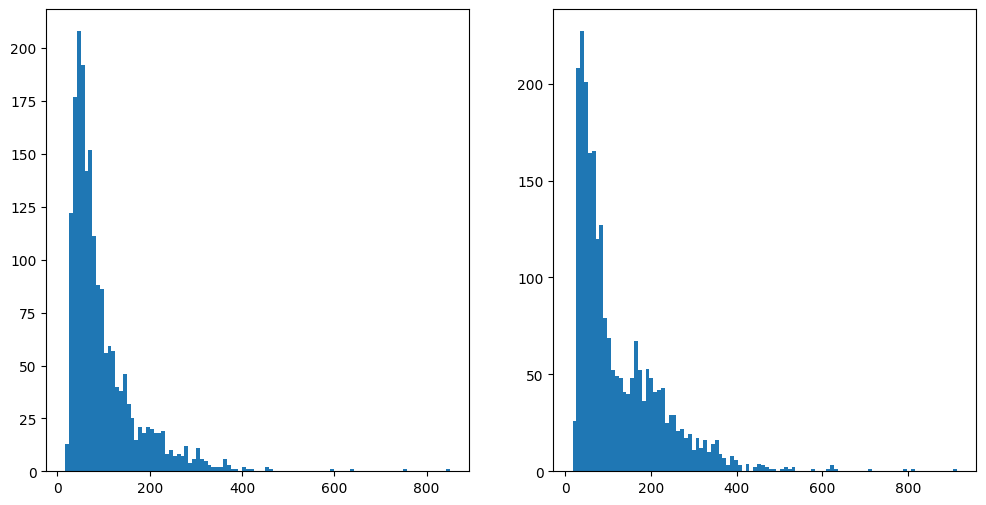

In [70]:
possible_overtag_bc_frag = pd.read_csv('/mnt/hdd_bob/syy/adipose/atac/res/AB_ATAC_FL_TAM_SQ/_possible_overtag_bc_frag.tsv', sep='\t', header=None)
fig, ax = plt.subplots(1, 2, figsize=(12,6))

possible_good_bc_frag = pd.read_csv('/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000/_possible_goodbc_frag.tsv', sep='\t', header=None)

ax[0].hist(possible_overtag_bc_frag[2] - possible_overtag_bc_frag[1], log=False, bins=100, label='overtag?')

ax[1].hist(possible_good_bc_frag[2] - possible_good_bc_frag[1], log=False, bins=100, label='good bc?')

In [43]:
all_df.loc['AGGATTATCTATATGC-1']

total_fragments_entropypeaks         6941
frag_overlap_entropy_peaks         2840.0
frag_overlap_entropy_peaks%     40.916294
total_fragments_peaks                6941
frag_overlap_peaks                 2690.0
frag_overlap_peaks%             38.755223
entropy                          0.074606
entropy_mixdist_c                0.375141
entropy_open_region              0.606157
Entropy_open_region_noadj        0.805068
mle_lambda                       0.139205
P0_open_region                    0.87005
p_closed_state                   0.937508
kl_divergence                    2.043295
1-P0                              0.12995
cr_bc                                True
log(total_fragments)             3.841422
log(entropy)                    -1.127225
Name: AGGATTATCTATATGC-1, dtype: object

In [74]:
7/0.34

20.588235294117645

ValueError: 'a' cannot be empty unless no samples are taken

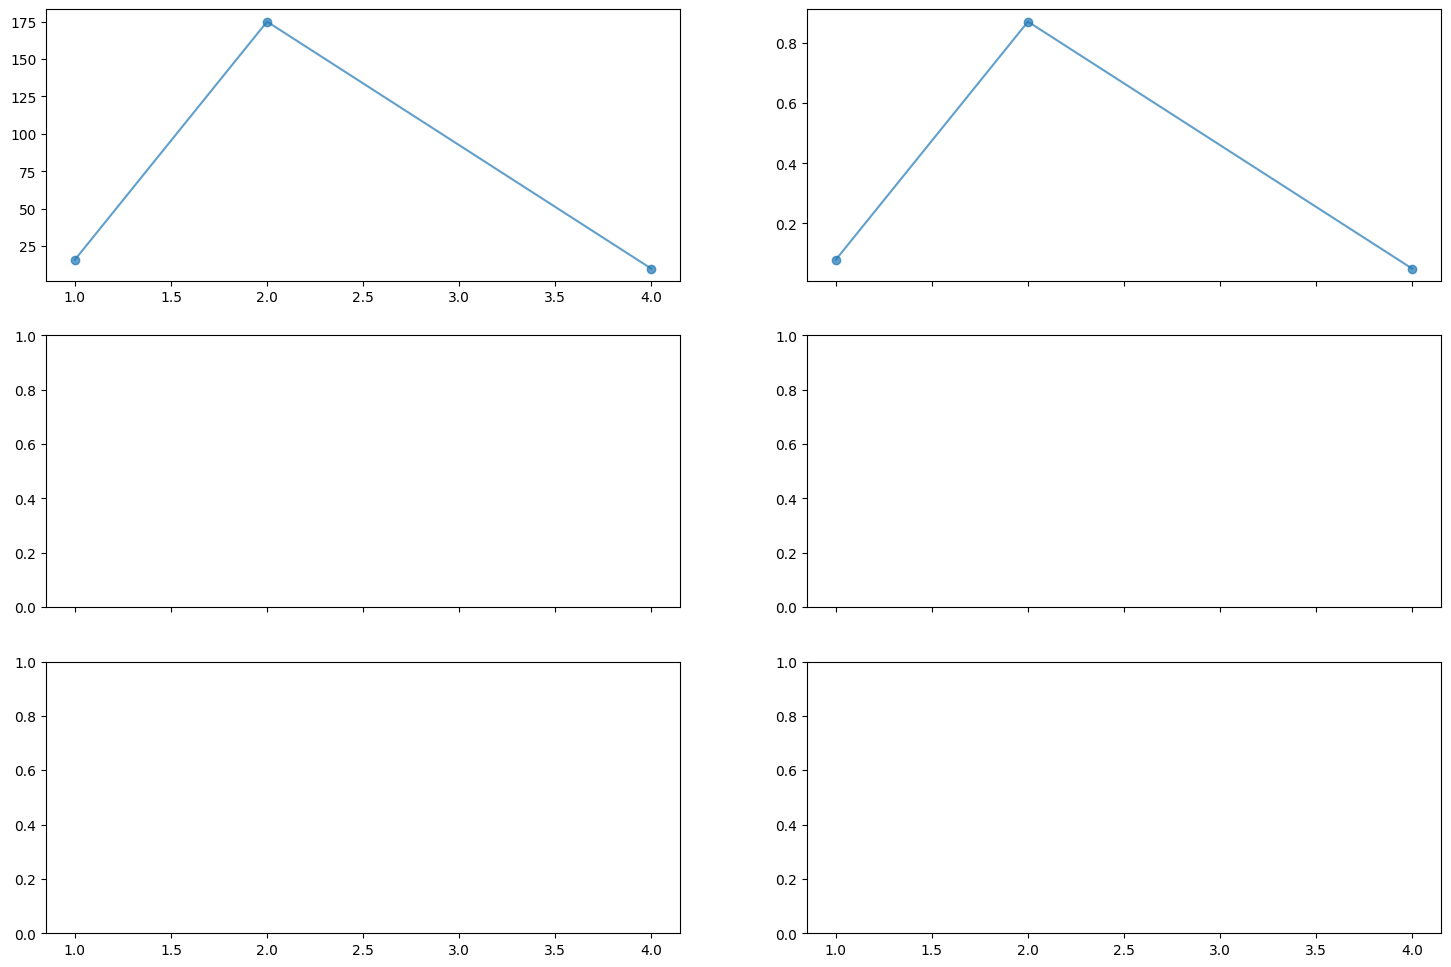

In [64]:
subset_df = all_df.loc[(all_df['frag_overlap_entropy_peaks%'] < 10) & (all_df['log(total_fragments)'] < 3.5) & (all_df['log(total_fragments)'] > 3.2) ]

good_df = all_df.loc[(all_df['frag_overlap_entropy_peaks%'] > 40) & (all_df['log(total_fragments)'] < 2.7) & (all_df['log(total_fragments)'] > 3.2) ]

crazy_df = all_df.loc[(all_df['entropy_mixdist_c'] > 10 ** (-.7)) & (all_df['log(total_fragments)'] > 3)]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 80, 85

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_mixdist_c']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])   
        
          
        ax[0, 0].plot(val[1:], freq[1:], marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}, ',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_mixdist_c']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        
        
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()} ',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_mixdist_c']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])

        
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()


In [ ]:
subset_df = all_df[(all_df['frag_overlap_entropy_peaks%'] < 20) & (all_df['log(total_fragments)'] < 3.5) & (all_df['log(total_fragments)'] > 3.2) ]

good_df = all_df[(all_df['frag_overlap_entropy_peaks%'] > 40) & (all_df['log(total_fragments)'] < 3.5) & (all_df['log(total_fragments)'] > 3.2) ]

crazy_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-.7)) & (all_df['log(total_fragments)'] > 3)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 77, 82

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq)     
        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val, freq, marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val, freq, marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

## Set 2

In [ ]:
subset_df = all_df.loc[(all_df['frag_overlap_entropy_peaks%'] < 10) & (all_df['log(total_fragments)'] > 3.5) & (all_df['log(total_fragments)'] < 3.8)  ]

good_df = all_df.loc[(all_df['frag_overlap_entropy_peaks%'] > 40) & (all_df['log(total_fragments)'] > 3.5)  & (all_df['log(total_fragments)'] < 3.8)  ]

crazy_df = all_df.loc[(all_df['entropy_mixdist_c'] > 10 ** (-.7)) & (all_df['log(total_fragments)'] > 3)]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 80, 85

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_mixdist_c']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])   
        
          
        ax[0, 0].plot(val[1:], freq[1:], marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}, ',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_mixdist_c']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        
        
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()} ',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_mixdist_c']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])

        
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()


In [ ]:
bad_df = all_df[(all_df['entropy_final'] < 10 ** (-1.3)) & (all_df['log(total_fragments)'] > 3.4) & (all_df['frag_overlap_entropy_peaks%'] < 15) ]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.3)) & (all_df['log(total_fragments)'] > 3.4) & (all_df['frag_overlap_entropy_peaks%'] > 40)]

crazy_df = all_df[(all_df['entropy_final'] > 10 ** (-1.3)) & (all_df['log(total_fragments)'] > 4)]
fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq)     
        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val, freq, marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())

        val = val[freq != None]
        freq = freq[freq != None]
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val, freq, marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

In [ ]:
entropycut_df = all_df[all_df['entropy_final'] > 10 ** (-1.3)]

In [ ]:
all_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(np.log10(entropycut_df['entropy_final']), entropycut_df['1-P0'], c=entropycut_df['frag_overlap_entropy_peaks%'], cmap='viridis')

# Plot entropy of mixture distribution

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')